In [1]:
import pandas as pd 
import torch
import torch.nn.functional as F
import pickle
import torch.nn as nn
import random
import numpy as np
import matplotlib.pyplot as plt
from torch_geometric.utils import negative_sampling
from sklearn.metrics import roc_auc_score
from torch_geometric.transforms import RandomLinkSplit
import torch.optim as optim
from torch_geometric.data import Data
from sklearn.preprocessing import MultiLabelBinarizer
import copy
from funciones import *

In [2]:
def set_seed(seed=42):
    """Congela todas las fuentes de aleatoriedad"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [3]:
with open("Grafo/grafo_lookiero.gpickle", "rb") as f:
    G = pickle.load(f)

In [4]:
first_node_id = list(G.nodes)[0]
print(f"ID del nodo: {first_node_id}")
print(f"Atributos: {G.nodes[first_node_id]}")

ID del nodo: 6e6b4255-006a-4d13-b312-3b1426290d8e
Atributos: {'id_producto': '6e6b4255-006a-4d13-b312-3b1426290d8e', 'title': 'Poly Pant deeluxe', 'lookiero': '{"size": "L", "format": "L"}, {"size": "M", "format": "M"}, {"size": "S", "format": "S"}, {"size": "XL", "format": "XL"}, {"size": "XS", "format": "XS"}', 'marca': 'BRAND117', 'fit': 'tight', 'style': 'casual', 'weather': 'warm_season', 'tipo_producto': 'Pant', 'Nivel': '1.1', 'Estampado': 'neutros', 'colores': 'A', 'color_groups': {'A'}, 'sizes_set': {'M', 'XL', 'XS', 'L', 'S'}, 'color_final': 'A'}


No tenemos atributos, por lo que habrá que extraerlos del df_vectores para obtener las features

In [5]:
node_ids = list(G.nodes())
data_rows = []

for n in node_ids:
    attrs = G.nodes[n]
    
    row = {
        'id': n,
        'fit': attrs.get('fit', 'Unknown'),
        'style': attrs.get('style', 'Unknown'),
        'weather': attrs.get('weather', 'Unknown'),
        'Estampado': attrs.get('Estampado', 'Unknown'),
        'Nivel': attrs.get('Nivel', '0'),
        
        'color_groups': list(attrs.get('color_groups', [])), 
        'sizes_set': list(attrs.get('sizes_set', []))
    }
    data_rows.append(row)

df_raw = pd.DataFrame(data_rows).set_index('id')

df_raw['sub_nivel'] = pd.to_numeric(df_raw['Nivel'], errors='coerce').fillna(0)

print(f"Datos extraídos: {df_raw.shape}")
print(df_raw.head(2))

Datos extraídos: (1125, 8)
                                           fit   style      weather  \
id                                                                    
6e6b4255-006a-4d13-b312-3b1426290d8e     tight  casual  warm_season   
2ccf1dc1-0e59-4cc7-8c5f-ee7a7d59a750  straight    boho  warm_season   

                                        Estampado Nivel color_groups  \
id                                                                     
6e6b4255-006a-4d13-b312-3b1426290d8e      neutros   1.1          [A]   
2ccf1dc1-0e59-4cc7-8c5f-ee7a7d59a750  geometricos   2.1         [NT]   

                                              sizes_set  sub_nivel  
id                                                                  
6e6b4255-006a-4d13-b312-3b1426290d8e  [M, XL, XS, L, S]        1.1  
2ccf1dc1-0e59-4cc7-8c5f-ee7a7d59a750      [S, M, L, XS]        2.1  


In [6]:
simple_cols = ['fit', 'style', 'weather', 'Estampado', 'Nivel']
df_simple = pd.get_dummies(df_raw[simple_cols])

mlb_colors = MultiLabelBinarizer(sparse_output=False)
colors_matrix = mlb_colors.fit_transform(df_raw['color_groups'])
df_colors = pd.DataFrame(
    colors_matrix, 
    columns=[f"color_{c}" for c in mlb_colors.classes_], 
    index=df_raw.index
)

mlb_sizes = MultiLabelBinarizer(sparse_output=False)
sizes_matrix = mlb_sizes.fit_transform(df_raw['sizes_set'])
df_sizes = pd.DataFrame(
    sizes_matrix, 
    columns=[f"size_{c}" for c in mlb_sizes.classes_], 
    index=df_raw.index
)

df_features_final = pd.concat([df_simple, df_colors, df_sizes], axis=1)

df_features_final = df_features_final.astype(float)

print(f"Matriz de Features creada. Dimensiones: {df_features_final.shape}")

Matriz de Features creada. Dimensiones: (1125, 44)


In [7]:
x = torch.tensor(df_features_final.values, dtype=torch.float)

node_ids = df_features_final.index.tolist()
id_to_idx = {id_str: i for i, id_str in enumerate(node_ids)}

edges_src = []
edges_dst = []

for u, v in G.edges():
    if u in id_to_idx and v in id_to_idx:
        edges_src.append(id_to_idx[u])
        edges_dst.append(id_to_idx[v])

edge_index = torch.tensor([edges_src, edges_dst], dtype=torch.long)

data = Data(x=x, edge_index=edge_index)
print(data)

Data(x=[1125, 44], edge_index=[2, 282376])


In [8]:
set_seed(42)

transform = RandomLinkSplit(
    num_val=0.1,  
    num_test=0.1, 
    is_undirected=True,
    add_negative_train_samples=False
)

train_data, val_data, test_data = transform(data)

print("Datos listos para entrenamiento:")
print(f"Train edges: {train_data.edge_label_index.shape[1]}")
print(f"Val edges: {val_data.edge_label_index.shape[1]}")
print(f"Test edges: {test_data.edge_label_index.shape[1]}")

Datos listos para entrenamiento:
Train edges: 225902
Val edges: 56474
Test edges: 56474


In [9]:
def train_link_predictor(model, train_data, val_data, optimizer, criterion, n_epochs=1000, patience=50):
    losses = []
    val_aucs = []
    
    best_val_auc = 0
    patience_counter = 0
    best_model_weights = None 

    for epoch in range(n_epochs):
        model.train() 
        optimizer.zero_grad()
        
        current_epoch = epoch + 1 
        
        z = model.encode(train_data.x, train_data.edge_index)
        
        neg_edge_index = negative_sampling(
            edge_index=train_data.edge_index, 
            num_nodes=train_data.num_nodes,
            num_neg_samples=train_data.edge_label_index.size(1), 
            method='sparse'
        )
        
        edge_label_index = torch.cat([train_data.edge_label_index, neg_edge_index], dim=-1)
        edge_label = torch.cat([train_data.edge_label, train_data.edge_label.new_zeros(neg_edge_index.size(1))], dim=0)
        
        out = model.decode(z, edge_label_index).view(-1)
        loss = criterion(out, edge_label)
        loss.backward()
        optimizer.step()
        
        val_auc = test(model, val_data)
        val_aucs.append(val_auc)
        losses.append(loss.item())
        
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            patience_counter = 0
            best_model_weights = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1
            
        if current_epoch == 1 or current_epoch % 10 == 0:
            print(f"Epoch: {current_epoch:03d}, Loss: {loss.item():.4f}, Val AUC: {val_auc:.4f}")

        if patience_counter >= patience:
            print(f"Early Stopping en época {current_epoch}. Récord final: {best_val_auc:.4f}")
            break
                
    if best_model_weights is not None:
        model.load_state_dict(best_model_weights)
        
    return model, losses, val_aucs

@torch.no_grad()
def test(model, data):
    model.eval()
    z = model.encode(data.x, data.edge_index)
    out = model.decode(z, data.edge_label_index).view(-1)
    return roc_auc_score(data.edge_label.cpu().numpy(), out.sigmoid().cpu().numpy())


Entrenando: SAGE...
Epoch: 001, Loss: 0.7610, Val AUC: 0.5656
Epoch: 010, Loss: 0.6039, Val AUC: 0.7066
Epoch: 020, Loss: 0.5902, Val AUC: 0.7095
Epoch: 030, Loss: 0.5825, Val AUC: 0.7189
Epoch: 040, Loss: 0.5783, Val AUC: 0.7190
Epoch: 050, Loss: 0.5765, Val AUC: 0.7162
Epoch: 060, Loss: 0.5760, Val AUC: 0.7167
Epoch: 070, Loss: 0.5754, Val AUC: 0.7165
Epoch: 080, Loss: 0.5755, Val AUC: 0.7162
Epoch: 090, Loss: 0.5745, Val AUC: 0.7163
Epoch: 100, Loss: 0.5750, Val AUC: 0.7168
Epoch: 110, Loss: 0.5739, Val AUC: 0.7167
Epoch: 120, Loss: 0.5742, Val AUC: 0.7173
Epoch: 130, Loss: 0.5739, Val AUC: 0.7170
Epoch: 140, Loss: 0.5736, Val AUC: 0.7180
Epoch: 150, Loss: 0.5750, Val AUC: 0.7178
Epoch: 160, Loss: 0.5739, Val AUC: 0.7182
Epoch: 170, Loss: 0.5742, Val AUC: 0.7172
Epoch: 180, Loss: 0.5738, Val AUC: 0.7195
Epoch: 190, Loss: 0.5742, Val AUC: 0.7176
Epoch: 200, Loss: 0.5738, Val AUC: 0.7167
Epoch: 210, Loss: 0.5745, Val AUC: 0.7199
Epoch: 220, Loss: 0.5741, Val AUC: 0.7165
Epoch: 230, L

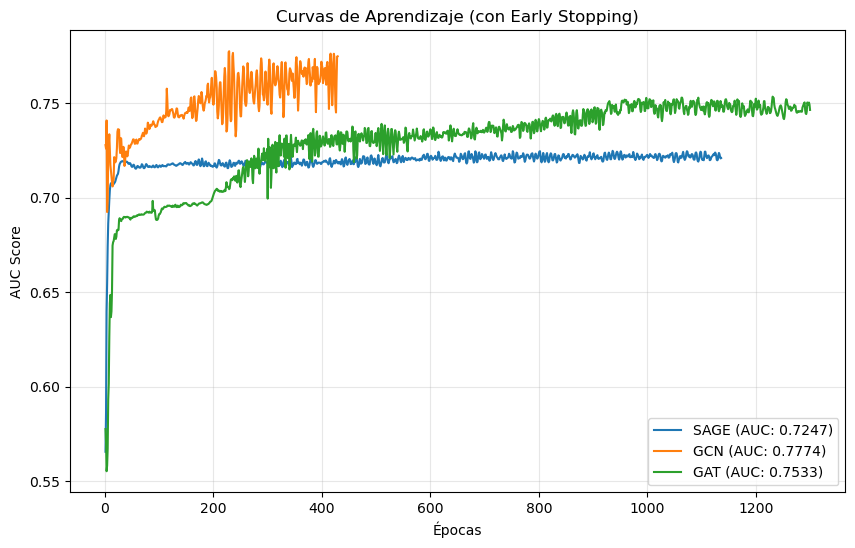

In [10]:
architectures = ['SAGE', 'GCN', 'GAT']
results = {} 

for arch in architectures:
    print(f"\nEntrenando: {arch}...")
    
    set_seed(42)
    model = LookRecommender(
        in_channels=data.num_features, 
        hidden_channels=64, 
        out_channels=32,
        arch=arch,
        heads=2 
    )
    
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.BCEWithLogitsLoss()
    
    _, losses, val_aucs = train_link_predictor(
        model=model, 
        train_data=train_data, 
        val_data=val_data, 
        optimizer=optimizer, 
        criterion=criterion, 
        n_epochs=1300,
        patience=200
    )
    
    best_score_achieved = max(val_aucs)
    
    results[arch] = {
        'losses': losses,
        'val_aucs': val_aucs,
        'final_score': best_score_achieved
    }
    
    print(f"{arch} Terminado. Mejor AUC conseguido: {best_score_achieved:.4f}")

print("Torneo finalizado.")

plt.figure(figsize=(10, 6))
for arch, res in results.items():
    epochs = range(1, len(res['val_aucs']) + 1)
    plt.plot(epochs, res['val_aucs'], label=f"{arch} (AUC: {res['final_score']:.4f})")

plt.xlabel('Épocas')
plt.ylabel('AUC Score')
plt.title('Curvas de Aprendizaje (con Early Stopping)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

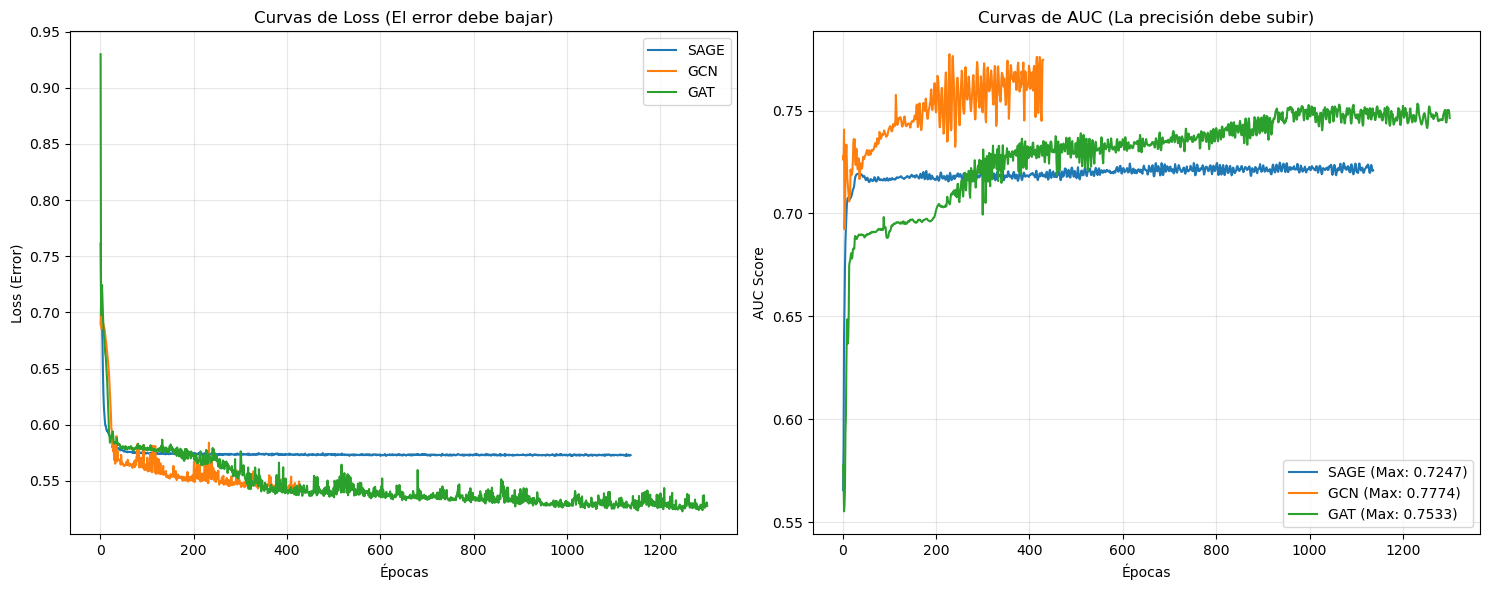

In [11]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1) 
for arch, res in results.items():
    epochs = range(1, len(res['losses']) + 1)
    plt.plot(epochs, res['losses'], label=f"{arch}")

plt.xlabel('Épocas')
plt.ylabel('Loss (Error)')
plt.title('Curvas de Loss (El error debe bajar)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2) 
for arch, res in results.items():
    epochs = range(1, len(res['val_aucs']) + 1)
    plt.plot(epochs, res['val_aucs'], label=f"{arch} (Max: {res['final_score']:.4f})")

plt.xlabel('Épocas')
plt.ylabel('AUC Score')
plt.title('Curvas de AUC (La precisión debe subir)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
print("Entrenando el modelo DEFINITIVO (GCN)...")

set_seed(42)
final_model = LookRecommender(
    in_channels=data.num_features, 
    hidden_channels=64, 
    out_channels=32,
    arch='GCN'
)

optimizer = optim.Adam(final_model.parameters(), lr=0.01)
criterion = nn.BCEWithLogitsLoss()

final_model, losses, val_aucs = train_link_predictor(
    model=final_model, 
    train_data=train_data, 
    val_data=val_data, 
    optimizer=optimizer, 
    criterion=criterion,
    n_epochs=1500,
    patience=300
)

print(f"Modelo Final GCN listo. AUC alcanzado: {val_aucs[-1]:.4f}")

Entrenando el modelo DEFINITIVO (GCN)...
Epoch: 001, Loss: 0.6894, Val AUC: 0.7277
Epoch: 010, Loss: 0.6837, Val AUC: 0.7172
Epoch: 020, Loss: 0.6365, Val AUC: 0.7192
Epoch: 030, Loss: 0.5688, Val AUC: 0.7311
Epoch: 040, Loss: 0.5689, Val AUC: 0.7236
Epoch: 050, Loss: 0.5649, Val AUC: 0.7291
Epoch: 060, Loss: 0.5673, Val AUC: 0.7285
Epoch: 070, Loss: 0.5624, Val AUC: 0.7342
Epoch: 080, Loss: 0.5828, Val AUC: 0.7387
Epoch: 090, Loss: 0.5710, Val AUC: 0.7394
Epoch: 100, Loss: 0.5624, Val AUC: 0.7415
Epoch: 110, Loss: 0.5625, Val AUC: 0.7423
Epoch: 120, Loss: 0.5563, Val AUC: 0.7463
Epoch: 130, Loss: 0.5560, Val AUC: 0.7441
Epoch: 140, Loss: 0.5579, Val AUC: 0.7433
Epoch: 150, Loss: 0.5545, Val AUC: 0.7447
Epoch: 160, Loss: 0.5547, Val AUC: 0.7451
Epoch: 170, Loss: 0.5538, Val AUC: 0.7446
Epoch: 180, Loss: 0.5512, Val AUC: 0.7491
Epoch: 190, Loss: 0.5530, Val AUC: 0.7602
Epoch: 200, Loss: 0.5507, Val AUC: 0.7491
Epoch: 210, Loss: 0.5683, Val AUC: 0.7485
Epoch: 220, Loss: 0.5560, Val AUC: 

In [13]:
test_auc = test(final_model, test_data)
print(f"AUC Final en Test (Realidad): {test_auc:.4f}")

AUC Final en Test (Realidad): 0.7819


In [14]:
torch.save(final_model, 'Modelos/modelo_gcn.pkl')

In [15]:
@torch.no_grad()
def recommend_for_new_item(model, new_item_features, data, top_k=5):
    """
    Genera recomendaciones para una prenda NUNCA VISTA antes.
    """
    model.eval()
    
    z_existing = model.encode(data.x, data.edge_index)
    
    empty_edge_index = torch.tensor([[],[]], dtype=torch.long)
    
    z_new_item = model.conv1(new_item_features, empty_edge_index).relu()
    z_new_item = model.conv2(z_new_item, empty_edge_index)
    
    scores = (z_new_item * z_existing).sum(dim=-1)
    
    top_scores, top_indices = torch.topk(scores, k=top_k)
    
    return top_indices.numpy(), top_scores.numpy()

dummy_new_item = torch.rand((1, data.num_features)) 

indices, scores = recommend_for_new_item(final_model, dummy_new_item, data)

print("IDs de productos recomendados para la nueva prenda:")
for idx in indices:
    print(f"- {node_ids[idx]}") 

IDs de productos recomendados para la nueva prenda:
- 8780d58a-9535-4a6e-998c-696b4f765111
- 8f6493a1-33fa-4b08-bc12-4900d1113a5b
- ae8506e2-16d8-4d5a-8d1f-5d928f54b3ee
- 3d0f7537-92e7-4358-82a5-7ee0c1aa4bb5
- d652fd63-6ffe-4d43-9c21-37c9c6f43b6c


Creación de looks a partir de prenda nueva

In [16]:
node_ids = list(G.nodes())
meta_data = []

for n in node_ids:
    attrs = G.nodes[n]

    nivel_str = attrs.get('Nivel', '0')
    
    meta_data.append({
        'id': n,
        'sub_nivel_raw': nivel_str
    })

df_aligned = pd.DataFrame(meta_data).set_index('id')

df_aligned['sub_nivel'] = pd.to_numeric(df_aligned['sub_nivel_raw'], errors='coerce').fillna(0)

In [17]:
dummy_item = torch.randn((1, data.num_features))
subnivel_prueba = 2.3 

best_looks = generate_best_outfits(
    model=final_model,
    new_item_features=dummy_item,
    new_item_sublevel=subnivel_prueba,
    data=data,
    node_ids=node_ids,
    df_meta=df_aligned,
    top_k=3
)

--- Top 3 Outfits Generados (Subnivel Prenda Nueva: 2.3) ---
LOOK 1 (Score: 0.85)
   1. [NUEVA] Prenda actual (Nivel: 2.3)
   2. ed6f3632-46ab-491a-8bc6-bec0e5c5409b (Nivel: 1.1) - Score: 0.66
   3. 00cef638-ccb2-4ed6-8256-1cd62a187bf3 (Nivel: 2.1) - Score: 0.19
------------------------------
LOOK 2 (Score: 0.59)
   1. [NUEVA] Prenda actual (Nivel: 2.3)
   2. 8cbed41b-7e50-4ab7-be33-fb3d6d4730ab (Nivel: 1.1) - Score: 0.40
   3. 00cef638-ccb2-4ed6-8256-1cd62a187bf3 (Nivel: 2.1) - Score: 0.19
------------------------------
LOOK 3 (Score: 0.54)
   1. [NUEVA] Prenda actual (Nivel: 2.3)
   2. e9915d28-1516-4fac-96e9-51f65a8ecee5 (Nivel: 1.1) - Score: 0.35
   3. 00cef638-ccb2-4ed6-8256-1cd62a187bf3 (Nivel: 2.1) - Score: 0.19
------------------------------


In [18]:
datos_produccion = {'graph_data': data, 'df_meta': df_aligned, 'node_ids': node_ids }
torch.save(datos_produccion, 'Datos/Transformados/datos_sistema.pt')